In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from pyspark.sql import SparkSession

# 初始化 Spark 会话
spark = SparkSession.builder \
    .appName("ReadParquet") \
    .getOrCreate()

# 读取 parquet 文件
df = spark.read.parquet("/content/drive/MyDrive/534_data_new/floor_Ground Floor/")


# 显示数据
df.show()

+---------+------------+-----------------+------------------+--------------------+--------------------+
|     Site|       Level|    ClientMacAddr|               lat|                 lng|           localtime|
+---------+------------+-----------------+------------------+--------------------+--------------------+
|UK Office|Ground Floor|00:c2:c6:f9:2f:9f|  51.4603795126194|-0.93271693810247491|2020-05-17 05:36:...|
|UK Office|Ground Floor|ec:ad:b8:7d:23:e8|51.460382160297421| -0.9325589450338545|2020-05-17 05:36:...|
|UK Office|Ground Floor|48:a4:72:ae:11:81|51.460376805746371|-0.93254628726650168|2020-05-17 05:36:...|
|UK Office|Ground Floor|00:23:a7:e7:96:0c|51.460549420265949|   -0.93238177654464|2020-05-17 05:36:...|
|UK Office|Ground Floor|e4:a7:a0:99:bc:2c|51.460500750207053|-0.93236695885850351|2020-05-17 05:36:...|
|UK Office|Ground Floor|14:ab:c5:09:b6:f9|  51.4605404041332|-0.93232569931998854|2020-05-17 05:36:...|
|UK Office|Ground Floor|fc:03:9f:07:af:f4|51.460818539966809|  -

In [ ]:
from pyspark.sql.functions import col, to_timestamp, regexp_replace

# 设置解析策略为 CORRECTED（推荐）
spark.conf.set("spark.sql.legacy.timeParserPolicy", "CORRECTED")

# 移除 UTC 并使用可选毫秒格式
df = df.withColumn(
    "localtime",
    to_timestamp(regexp_replace(col("localtime"), " UTC", ""), "yyyy-MM-dd HH:mm:ss[.SSS]")
)
# 将 lat 和 lng 转换为 double 类型
df = df.withColumn("lat", df["lat"].cast("double")) \
       .withColumn("lng", df["lng"].cast("double"))
# 查看结果
df.show()

+---------+------------+-----------------+------------------+-------------------+--------------------+
|     Site|       Level|    ClientMacAddr|               lat|                lng|           localtime|
+---------+------------+-----------------+------------------+-------------------+--------------------+
|UK Office|Ground Floor|00:c2:c6:f9:2f:9f|  51.4603795126194|-0.9327169381024749|2020-05-17 05:36:...|
|UK Office|Ground Floor|ec:ad:b8:7d:23:e8| 51.46038216029742|-0.9325589450338545|2020-05-17 05:36:...|
|UK Office|Ground Floor|48:a4:72:ae:11:81| 51.46037680574637|-0.9325462872665017|2020-05-17 05:36:...|
|UK Office|Ground Floor|00:23:a7:e7:96:0c| 51.46054942026595|  -0.93238177654464|2020-05-17 05:36:...|
|UK Office|Ground Floor|e4:a7:a0:99:bc:2c| 51.46050075020705|-0.9323669588585035|2020-05-17 05:36:...|
|UK Office|Ground Floor|14:ab:c5:09:b6:f9|  51.4605404041332|-0.9323256993199885|2020-05-17 05:36:...|
|UK Office|Ground Floor|fc:03:9f:07:af:f4| 51.46081853996681| -0.93230763

In [ ]:
from pyspark.sql import functions as F
mac_count = df.groupBy("ClientMacAddr").count()
mac_count.orderBy(F.col("count").asc()).show(20, truncate=False)

+-----------------+-----+
|ClientMacAddr    |count|
+-----------------+-----+
|88:b4:a6:7d:8a:cc|1    |
|58:d9:c3:4f:50:f7|1    |
|88:b4:a6:dc:31:75|1    |
|80:58:f8:6b:8b:74|1    |
|80:58:f8:50:15:a3|1    |
|84:cf:bf:8a:54:29|1    |
|38:80:df:c6:ba:00|1    |
|88:b4:a6:bb:36:e6|1    |
|f0:79:60:8a:3a:01|1    |
|80:58:f8:2d:29:25|1    |
|dc:56:e7:89:11:0d|1    |
|f4:f5:24:7e:32:ad|1    |
|88:b4:a6:3a:5a:56|1    |
|d0:77:14:b8:4a:af|1    |
|80:58:f8:eb:b0:75|1    |
|80:58:f8:75:b9:10|1    |
|80:58:f8:4c:33:d2|1    |
|80:58:f8:00:c5:53|1    |
|80:58:f8:c8:45:9c|1    |
|80:58:f8:44:2d:f2|1    |
+-----------------+-----+
only showing top 20 rows



In [ ]:
from pyspark.sql import functions as F

# 1. 先统计每个 ClientMacAddr 出现的次数
mac_count = df.groupBy("ClientMacAddr").count()

# 2. 找出出现次数小于等于10的 ClientMacAddr
ten_counts = mac_count.filter(F.col("count") <= 10)

# 3. 取出需要删除的 ClientMacAddr 列表（可以 join 也可以用 left anti join）
df = df.join(ten_counts, on="ClientMacAddr", how="left_anti")

# 4. 打印结果
df.show()
print(df.count())

+-----------------+---------+------------+------------------+-------------------+--------------------+
|    ClientMacAddr|     Site|       Level|               lat|                lng|           localtime|
+-----------------+---------+------------+------------------+-------------------+--------------------+
|00:0b:82:d0:ff:35|UK Office|Ground Floor|51.460410549472826| -0.932611004897217|2020-05-17 05:10:...|
|00:0b:82:d0:ff:35|UK Office|Ground Floor|51.460418395557994|-0.9326294439774601|2020-05-17 05:10:...|
|00:0b:82:d0:ff:35|UK Office|Ground Floor|51.460418395557994|-0.9326294439774601|2020-05-17 05:10:...|
|00:0b:82:d0:ff:35|UK Office|Ground Floor|51.460418395557994|-0.9326294439774601|2020-05-17 05:09:...|
|00:0b:82:d0:ff:35|UK Office|Ground Floor|51.460418395557994|-0.9326294439774601|2020-05-17 05:09:...|
|00:0b:82:d0:ff:35|UK Office|Ground Floor|51.460418395557994|-0.9326294439774601|2020-05-17 05:09:...|
|00:0b:82:d0:ff:35|UK Office|Ground Floor|51.460418395557994|-0.932629443

In [ ]:
from pyspark.sql import functions as F

# 1. 统计每个 ClientMacAddr 的 lat 和 lng 的唯一数量
mac_counts = df.groupBy("ClientMacAddr").agg(
    F.countDistinct("lat").alias("lat_count"),
    F.countDistinct("lng").alias("lng_count")
)

# 2. 筛选 lat 和 lng 都只有一个唯一值的 MAC 地址
mac_with_unique_location = mac_counts.filter(
    (F.col("lat_count") == 1) & (F.col("lng_count") == 1)
).select("ClientMacAddr")

# 3. 从原始 df 中筛选出这些固定设施 MAC 的记录
unique_mac = df.join(mac_with_unique_location, on="ClientMacAddr", how="inner")

# 4. 查看数据
unique_mac.show()
print(unique_mac.count())

+-----------------+---------+------------+-----------------+-------------------+--------------------+
|    ClientMacAddr|     Site|       Level|              lat|                lng|           localtime|
+-----------------+---------+------------+-----------------+-------------------+--------------------+
|34:f6:4b:c2:12:26|UK Office|Ground Floor|51.46052010795695|-0.9322912526398738|2020-08-18 14:03:...|
|34:f6:4b:c2:12:26|UK Office|Ground Floor|51.46052010795695|-0.9322912526398738|2020-08-18 14:03:...|
|34:f6:4b:c2:12:26|UK Office|Ground Floor|51.46052010795695|-0.9322912526398738|2020-08-18 14:02:...|
|34:f6:4b:c2:12:26|UK Office|Ground Floor|51.46052010795695|-0.9322912526398738|2020-08-18 14:02:...|
|34:f6:4b:c2:12:26|UK Office|Ground Floor|51.46052010795695|-0.9322912526398738|2020-08-18 14:02:...|
|34:f6:4b:c2:12:26|UK Office|Ground Floor|51.46052010795695|-0.9322912526398738|2020-08-18 14:02:...|
|34:f6:4b:c2:12:26|UK Office|Ground Floor|51.46052010795695|-0.9322912526398738|20

In [ ]:
# 只保留 ClientMacAddr，去重后统计数量
unique_mac_count = unique_mac.select("ClientMacAddr").distinct().count()

print(unique_mac_count)

27153


In [ ]:
df_remaining = df.join(mac_with_unique_location, on="ClientMacAddr", how="left_anti")

# 查看剩下的数据
df_remaining.show()
print(df_remaining.count())

+-----------------+---------+------------+------------------+-------------------+--------------------+
|    ClientMacAddr|     Site|       Level|               lat|                lng|           localtime|
+-----------------+---------+------------+------------------+-------------------+--------------------+
|00:0b:82:d0:ff:35|UK Office|Ground Floor|51.460410549472826| -0.932611004897217|2020-05-17 05:10:...|
|00:0b:82:d0:ff:35|UK Office|Ground Floor|51.460418395557994|-0.9326294439774601|2020-05-17 05:10:...|
|00:0b:82:d0:ff:35|UK Office|Ground Floor|51.460418395557994|-0.9326294439774601|2020-05-17 05:10:...|
|00:0b:82:d0:ff:35|UK Office|Ground Floor|51.460418395557994|-0.9326294439774601|2020-05-17 05:09:...|
|00:0b:82:d0:ff:35|UK Office|Ground Floor|51.460418395557994|-0.9326294439774601|2020-05-17 05:09:...|
|00:0b:82:d0:ff:35|UK Office|Ground Floor|51.460418395557994|-0.9326294439774601|2020-05-17 05:09:...|
|00:0b:82:d0:ff:35|UK Office|Ground Floor|51.460418395557994|-0.932629443

In [ ]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window
import math
from pyspark.sql.types import DoubleType
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # 地球半径，单位为公里
    phi1 = math.radians(lat1)
    phi2 = math.radians(lat2)
    delta_phi = math.radians(lat2 - lat1)
    delta_lambda = math.radians(lon2 - lon1)

    a = math.sin(delta_phi / 2)**2 + math.cos(phi1) * math.cos(phi2) * math.sin(delta_lambda / 2)**2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
    return round(R * c * 1000, 3)  # 返回距离，单位为米
# 注册 UDF
haversine_udf = F.udf(haversine, DoubleType())

In [ ]:
# 按 ClientMacAddr 和 timestamp 排序
windowSpec = Window.partitionBy("ClientMacAddr").orderBy("localtime")
# 计算相邻记录的经纬度差值
df_remaining = df_remaining.withColumn("prev_lat", F.lag("lat").over(windowSpec)) \
       .withColumn("prev_lng", F.lag("lng").over(windowSpec)) \
       .withColumn("prev_localtime", F.lag("localtime").over(windowSpec))

In [ ]:
df_remaining = df_remaining.na.drop()

In [ ]:
df_remaining.show()

+-----------------+---------+---------+------------------+-------------------+--------------------+------------------+-------------------+--------------------+
|    ClientMacAddr|     Site|    Level|               lat|                lng|           localtime|          prev_lat|           prev_lng|      prev_localtime|
+-----------------+---------+---------+------------------+-------------------+--------------------+------------------+-------------------+--------------------+
|00:06:c6:92:a5:c1|UK Office|3rd Floor| 51.46046510522303|-0.9331322820155529|2020-03-12 12:24:...| 51.46046510522303|-0.9331322820155529|2020-03-12 12:24:...|
|00:06:c6:92:a5:c1|UK Office|3rd Floor| 51.46046510522303|-0.9331322820155529|2020-03-12 12:24:...| 51.46046510522303|-0.9331322820155529|2020-03-12 12:24:...|
|00:06:c6:92:a5:c1|UK Office|3rd Floor| 51.46046510522303|-0.9331322820155529|2020-03-12 12:24:...| 51.46046510522303|-0.9331322820155529|2020-03-12 12:24:...|
|00:06:c6:92:a5:c1|UK Office|3rd Floor| 

In [ ]:
df_remaining = df_remaining.withColumn("distance", haversine_udf("lat", "lng", "prev_lat", "prev_lng"))
df_remaining.select("distance").show()

+--------+
|distance|
+--------+
|   2.051|
|   2.933|
|  10.053|
|   3.431|
|   6.985|
|   7.298|
|   8.809|
|   5.293|
|  12.321|
|   9.723|
|   9.444|
|   9.327|
|  11.585|
|   2.576|
|   8.814|
|  10.823|
|   1.164|
|   0.577|
|  11.954|
|  12.442|
+--------+
only showing top 20 rows



In [ ]:
# 计算每次移动的距离
df_remaining = df_remaining.withColumn("distance", haversine_udf("lat", "lng", "prev_lat", "prev_lng"))

# 计算时间差（以秒为单位）
df_remaining = df_remaining.withColumn("time_diff", (F.unix_timestamp("localtime") - F.unix_timestamp("prev_localtime")))

# 计算速度（单位：米/秒）
df_remaining = df_remaining.withColumn("speed", F.when(F.col("time_diff") > 0, F.col("distance") / F.col("time_diff")).otherwise(0))

# 显示结果
df_remaining.select("ClientMacAddr", "localtime", "lat", "lng", "distance", "time_diff", "speed").show()


+-----------------+--------------------+------------------+-------------------+--------+---------+-------------------+
|    ClientMacAddr|           localtime|               lat|                lng|distance|time_diff|              speed|
+-----------------+--------------------+------------------+-------------------+--------+---------+-------------------+
|00:08:22:0a:c8:fb|2019-10-09 15:58:...|51.460934980704586|-0.9322198521339794|     0.0|        6|                0.0|
|00:08:22:0a:c8:fb|2019-10-09 15:59:...| 51.46078310568203|-0.9324445567588484|  22.968|       10|             2.2968|
|00:08:22:0a:c8:fb|2019-10-09 15:59:...| 51.46078310568203|-0.9324445567588484|     0.0|       10|                0.0|
|00:08:22:0a:c8:fb|2019-10-09 15:59:...| 51.46078310568203|-0.9324445567588484|     0.0|       10|                0.0|
|00:08:22:0a:c8:fb|2019-10-09 15:59:...| 51.46078310568203|-0.9324445567588484|     0.0|       10|                0.0|
|00:08:22:0a:c8:fb|2019-10-09 15:59:...| 51.4607

In [ ]:
from pyspark.sql.functions import col

df_remaining.select("speed").orderBy(col("speed").desc()).show()


+------+
| speed|
+------+
|66.854|
|61.712|
|61.349|
| 60.18|
|59.944|
|59.944|
|59.944|
|59.944|
|59.944|
|59.944|
|58.029|
|57.277|
|56.867|
| 56.69|
|56.583|
|55.073|
|54.993|
| 53.78|
|53.417|
|53.273|
+------+
only showing top 20 rows



In [ ]:
from pyspark.sql.functions import col

count = df_remaining.filter(col("speed") < 2).select("ClientMacAddr").distinct().count()
print("speed < 2 的不同 macaddress 数量为：", count)

speed < 2 的不同 macaddress 数量为： 4114


In [ ]:
# 过滤 speed > 2 的数据
df_filtered = df_remaining.filter(col("speed") > 2).select("ClientMacAddr", "lat", "lng")

# 转成 Pandas DataFrame
pdf = df_filtered.toPandas()
pdf

,ClientMacAddr,lat,lng
0,00:08:22:0a:c8:fb,51.460783,-0.932445
1,00:08:22:c6:bb:fb,51.460479,-0.932695
2,00:0b:82:d0:ff:35,51.460404,-0.932570
3,00:0b:82:d0:ff:35,51.460598,-0.932394
4,00:0b:82:d0:ff:35,51.460352,-0.932546
...,...,...,...
515897,fc:2a:9c:7e:6e:23,51.460783,-0.932270
515898,fc:2a:9c:7e:6e:23,51.460420,-0.932453
515899,fc:2a:9c:7e:6e:23,51.460640,-0.932335
515900,fc:2a:9c:7e:6e:23,51.460781,-0.932227


In [ ]:
import pandas as pd
pdf_1 = unique_mac.select("ClientMacAddr", "lat", "lng").toPandas()
df_merged = pd.concat([pdf, pdf_1], ignore_index=True)
df_merged

,ClientMacAddr,lat,lng
0,00:08:22:0a:c8:fb,51.460783,-0.932445
1,00:08:22:c6:bb:fb,51.460479,-0.932695
2,00:0b:82:d0:ff:35,51.460404,-0.932570
3,00:0b:82:d0:ff:35,51.460598,-0.932394
4,00:0b:82:d0:ff:35,51.460352,-0.932546
...,...,...,...
880302,80:58:f8:29:6d:8d,51.460786,-0.932225
880303,80:58:f8:29:6d:8d,51.460786,-0.932225
880304,80:58:f8:29:6d:8d,51.460786,-0.932225
880305,80:58:f8:29:6d:8d,51.460786,-0.932225


In [ ]:
fixed_mac_mode_coords = df_merged.groupby('ClientMacAddr')[['ClientMacAddr', 'lat', 'lng']].apply(lambda x: x.mode().iloc[0])
print(fixed_mac_mode_coords)

0                      ClientMacAddr        lat       lng
ClientMacAddr                                            
00:00:00:00:00:00  00:00:00:00:00:00  51.460442 -0.933014
00:08:22:0a:c8:fb  00:08:22:0a:c8:fb  51.460783 -0.932445
00:08:22:18:c4:fb  00:08:22:18:c4:fb  51.460943 -0.932167
00:08:22:24:bd:fb  00:08:22:24:bd:fb  51.460518 -0.932310
00:08:22:26:bb:fb  00:08:22:26:bb:fb  51.460352 -0.933096
...                              ...        ...       ...
fc:a6:26:2e:22:1d  fc:a6:26:2e:22:1d  51.460718 -0.932396
fc:a6:67:be:c0:a5  fc:a6:67:be:c0:a5  51.460402 -0.932651
fc:a6:67:d8:6c:b9  fc:a6:67:d8:6c:b9  51.460632 -0.932351
fc:aa:a7:f2:0c:24  fc:aa:a7:f2:0c:24  51.460444 -0.932278
fc:bc:c3:8d:4c:2e  fc:bc:c3:8d:4c:2e  51.460938 -0.932382

[41561 rows x 3 columns]


In [ ]:
fixed_mac_mode_coords.columns


Index(['ClientMacAddr', 'lat', 'lng'], dtype='object', name=0)

In [ ]:
import pandas as pd
import numpy as np

# 假设 fixed_mac_mode_coords 是一个 DataFrame，包含 ClientMacAddr, lat, lng
# 1. 随机选取 50 台设备
selected_macs = fixed_mac_mode_coords.sample(n=50, random_state=42).reset_index(drop=True)

# 2. 构建 2019-09-01 每 10 分钟的时间戳（144 个）
time_range = pd.date_range(start="2019-09-01 00:00:00", end="2019-09-01 23:50:00", freq="10min")

# 3. 设备和时间做笛卡尔积
device_time_grid = selected_macs.merge(
    pd.DataFrame({'localtime': time_range}),
    how='cross'
)

# 4. 模拟温度和压力（降低异常概率）
np.random.seed(42)

def simulate_temp():
    prob = np.random.rand()
    if prob < 0.98:
        return np.random.normal(25, 2)         # 正常
    elif prob < 0.988:
        return np.random.normal(37, 1)         # 可能泄漏
    else:
        return np.random.normal(42, 1.5)       # 重大泄漏

def simulate_pressure():
    prob = np.random.rand()
    if prob < 0.93:
        return np.random.normal(1.5, 0.2)       # 正常
    elif prob < 0.995:
        return np.random.normal(5.0, 0.5)       # 可能泄漏
    else:
        return np.random.normal(9.0, 0.3)       # 重大泄漏

# 5. 批量生成温度和压力
device_time_grid["temperature"] = [simulate_temp() for _ in range(len(device_time_grid))]
device_time_grid["pressure"] = [simulate_pressure() for _ in range(len(device_time_grid))]

# 6. 分类泄漏等级（根据你新给的标准）
def classify_leak(temp, pressure):
    if temp > 40 or pressure > 8.3:
        return "Severe Leakage"
    elif temp > 35 or pressure > 4:
        return "Potential Leakage"
    else:
        return "Normal"

device_time_grid["leak_level"] = device_time_grid.apply(
    lambda row: classify_leak(row["temperature"], row["pressure"]),
    axis=1
)

# 7. 整理字段并输出最终结果
df_simulated = device_time_grid.rename(columns={
    "lat": "latitude",
    "lng": "longitude"
})[["ClientMacAddr", "latitude", "longitude", "localtime", "temperature", "pressure", "leak_level"]]

# 展示前几行验证
df_simulated.head(10)

,ClientMacAddr,latitude,longitude,localtime,temperature,pressure,leak_level
0,a0:51:0b:1c:02:19,51.460938,-0.932382,2019-09-01 00:00:00,22.776240,1.192784,Normal
1,a0:51:0b:1c:02:19,51.460938,-0.932382,2019-09-01 00:10:00,25.637804,1.186806,Normal
2,a0:51:0b:1c:02:19,51.460938,-0.932382,2019-09-01 00:20:00,25.558083,1.382760,Normal
3,a0:51:0b:1c:02:19,51.460938,-0.932382,2019-09-01 00:30:00,27.021031,5.138749,Potential Leakage
4,a0:51:0b:1c:02:19,51.460938,-0.932382,2019-09-01 00:40:00,23.838244,1.723050,Normal
5,a0:51:0b:1c:02:19,51.460938,-0.932382,2019-09-01 00:50:00,23.949660,1.441201,Normal
6,a0:51:0b:1c:02:19,51.460938,-0.932382,2019-09-01 01:00:00,19.774902,1.336937,Normal
7,a0:51:0b:1c:02:19,51.460938,-0.932382,2019-09-01 01:10:00,26.900739,1.662585,Normal
8,a0:51:0b:1c:02:19,51.460938,-0.932382,2019-09-01 01:20:00,24.143908,1.433505,Normal
9,a0:51:0b:1c:02:19,51.460938,-0.932382,2019-09-01 01:30:00,23.515186,1.567994,Normal


In [ ]:
import plotly.express as px

# 重新确认时间格式
df_simulated["localtime"] = pd.to_datetime(df_simulated["localtime"])
df_simulated["localtime_str"] = df_simulated["localtime"].dt.strftime("%H:%M")

# 颜色映射
level_color = {
    "Normal": "green",
    "Potential Leakage": "orange",
    "Severe Leakage": "red"
}
center_lat = df_simulated["latitude"].mean()
center_lon = df_simulated["longitude"].mean()


lat_range = df_simulated["latitude"].max() - df_simulated["latitude"].min()
lon_range = df_simulated["longitude"].max() - df_simulated["longitude"].min()
buffer = 0.01

# 创建地图
fig = px.scatter_mapbox(
    df_simulated,
    lat="latitude",
    lon="longitude",
    color="leak_level",
    color_discrete_map=level_color,
    animation_frame="localtime_str",
    hover_name="ClientMacAddr",
    zoom=11,  # 初始缩放等级
    height=700,
    title="Real-Time Leakage Map for 50 Devices"
)

# 自动居中 & 设置合适缩放
fig.update_layout(
    mapbox_style="open-street-map",
    mapbox_center={"lat": center_lat, "lon": center_lon},
    mapbox_zoom=11,
    mapbox_bounds={
        "west": df_simulated["longitude"].min() - buffer,
        "east": df_simulated["longitude"].max() + buffer,
        "south": df_simulated["latitude"].min() - buffer,
        "north": df_simulated["latitude"].max() + buffer
    },
    margin={"r":0,"t":40,"l":0,"b":0}
)

fig.show()


In [ ]:
fig.write_html("leak_map_animated.html")
from google.colab import files
files.download("leak_map_animated.html")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

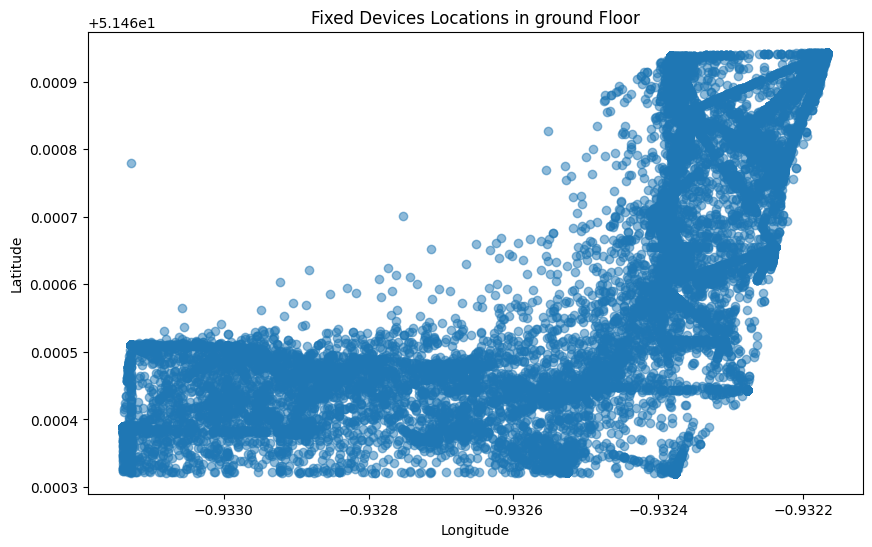

In [ ]:
#Ditribution of fixed devices in 3rd floor
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.scatter(fixed_mac_mode_coords['lng'], fixed_mac_mode_coords['lat'], alpha=0.5)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Fixed Devices Locations in ground Floor')
plt.show()